# 1. Data Exploration — Keypoint Detector

Explore what **YOLO Pose** extracts from our push-up frames, understand the 17 COCO keypoint schema, and verify that biomechanical angles (elbow, body-alignment) look sensible before committing to any training.

**Pipeline position:**
```
Video → Person Detector (done ✅) → Pose Estimator ← YOU ARE HERE
```

**Depends on:** `person_detector/` notebooks 1–4 completed and frames extracted to `person_detector/data/frames/`.

In [4]:
# Install dependencies if needed
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['ultralytics', 'opencv-python', 'matplotlib', 'pandas', 'tqdm', 'numpy']:
    install(pkg)
print('Dependencies ready.')

Dependencies ready.


In [5]:
import cv2
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT       = Path('..').resolve()            # pushup_judge/
PD_DIR     = ROOT / 'person_detector'
KD_DIR     = ROOT / 'keypoint_detector'
FRAMES_DIR = PD_DIR / 'data' / 'frames'     # extracted by person_detector nb2
DATA_DIR   = ROOT / 'data'

print('ROOT      :', ROOT)
print('PD_DIR    :', PD_DIR)
print('FRAMES_DIR:', FRAMES_DIR)

correct_frames = sorted((FRAMES_DIR / 'correct').rglob('*.jpg')) + \
                 sorted((FRAMES_DIR / 'correct').rglob('*.png'))
wrong_frames   = sorted((FRAMES_DIR / 'wrong').rglob('*.jpg'))   + \
                 sorted((FRAMES_DIR / 'wrong').rglob('*.png'))

print(f'\nCorrect frames : {len(correct_frames)}')
print(f'Wrong frames   : {len(wrong_frames)}')
print(f'Total frames   : {len(correct_frames) + len(wrong_frames)}')

ROOT      : /Users/haleytran/Downloads/pushup_judge
PD_DIR    : /Users/haleytran/Downloads/pushup_judge/person_detector
FRAMES_DIR: /Users/haleytran/Downloads/pushup_judge/person_detector/data/frames

Correct frames : 813
Wrong frames   : 1045
Total frames   : 1858


## 1.1 Frame Distribution

Unique correct videos: 76
Unique wrong videos  : 76


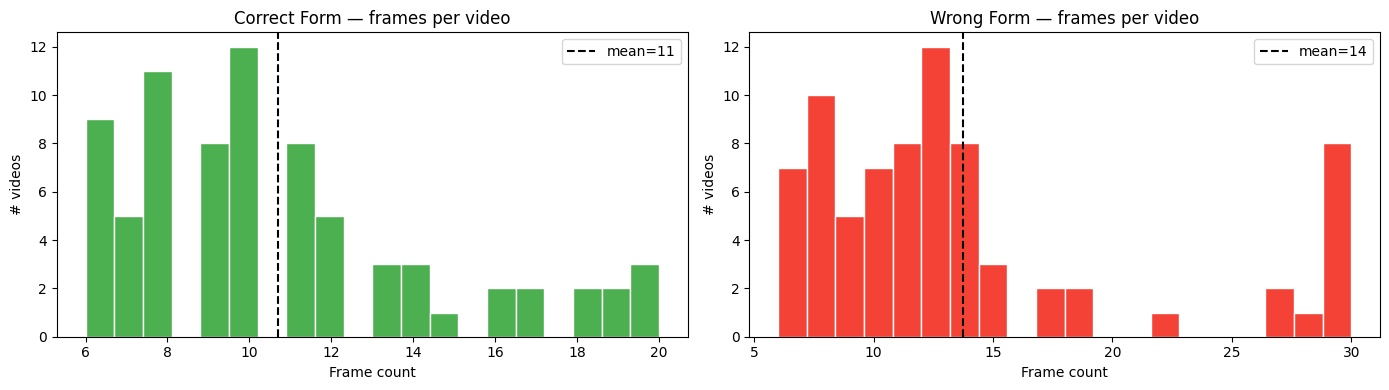

In [6]:
# ── Per-video frame count ─────────────────────────────────────────────────────
def count_per_video(frame_paths):
    counts = {}
    for p in frame_paths:
        vid = p.parent.name
        counts[vid] = counts.get(vid, 0) + 1
    return counts

correct_counts = count_per_video(correct_frames)
wrong_counts   = count_per_video(wrong_frames)

print(f'Unique correct videos: {len(correct_counts)}')
print(f'Unique wrong videos  : {len(wrong_counts)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, counts, label, color in zip(
    axes,
    [correct_counts, wrong_counts],
    ['Correct Form', 'Wrong Form'],
    ['#4CAF50', '#F44336']
):
    vals = list(counts.values())
    ax.hist(vals, bins=20, color=color, edgecolor='white')
    ax.set_title(f'{label} — frames per video')
    ax.set_xlabel('Frame count'); ax.set_ylabel('# videos')
    ax.axvline(np.mean(vals), color='black', linestyle='--', label=f'mean={np.mean(vals):.0f}')
    ax.legend()

plt.tight_layout()
plt.show()

## 1.2 Sample Frames — Correct vs Wrong Form

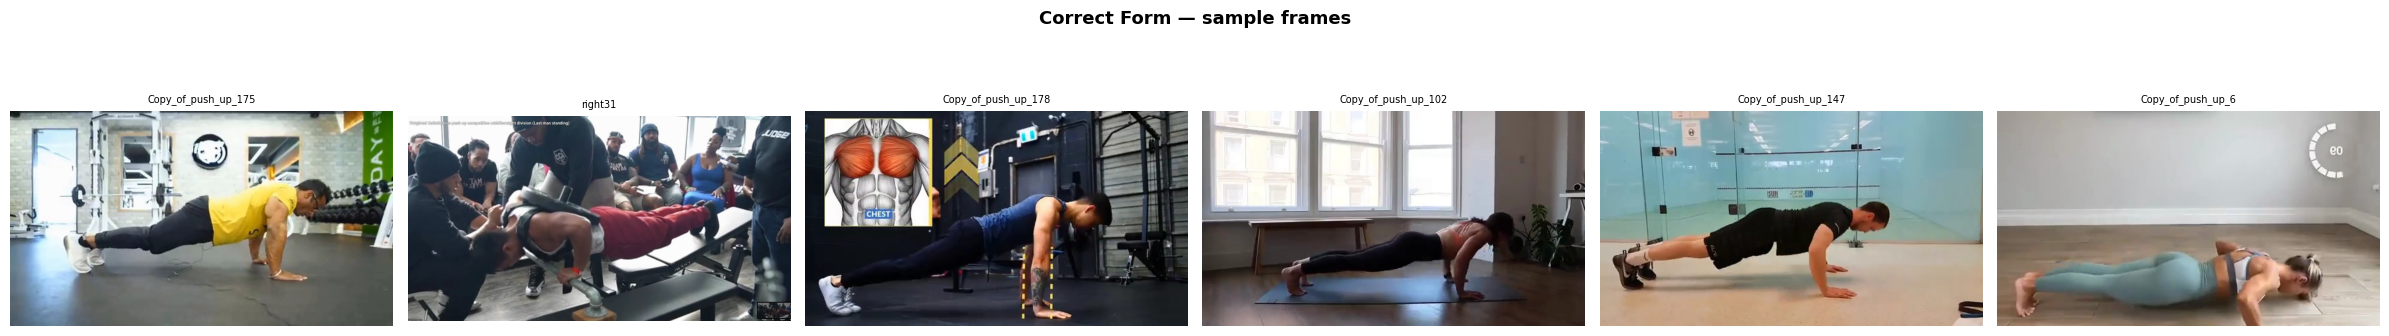

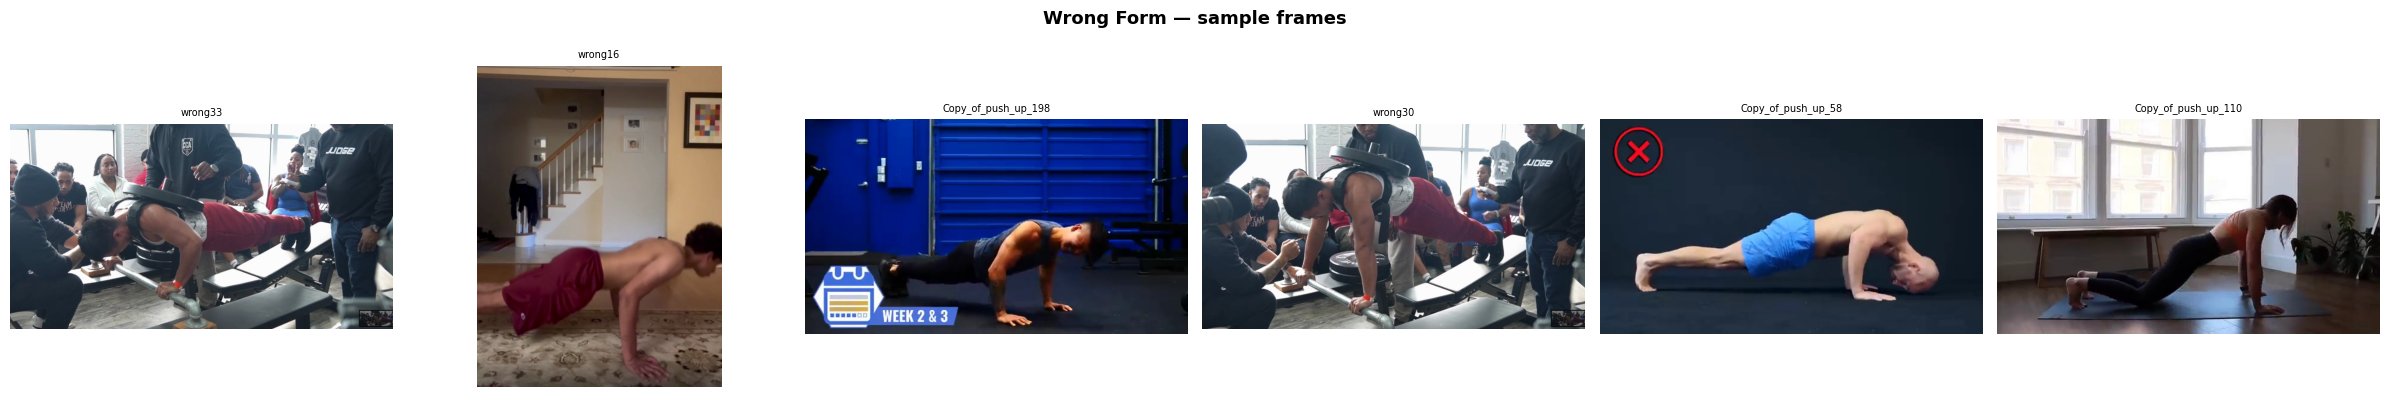

In [7]:
import random
random.seed(0)

def show_samples(paths, title, n=6, color=(0,255,0)):
    picks = random.sample(paths, min(n, len(paths)))
    fig, axes = plt.subplots(1, len(picks), figsize=(4*len(picks), 4))
    if len(picks) == 1: axes = [axes]
    for ax, p in zip(axes, picks):
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(p.parent.name, fontsize=7)
        ax.axis('off')
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

if correct_frames:
    show_samples(correct_frames, 'Correct Form — sample frames')
if wrong_frames:
    show_samples(wrong_frames, 'Wrong Form — sample frames')

## 1.3 COCO-17 Keypoint Schema

YOLO Pose outputs **17 keypoints** in COCO format.  
Each keypoint is `(x, y, confidence)`.  
Push-up relevant joints are highlighted.

| Index | Name | Push-up relevant |
|---|---|---|
| 0 | Nose | ✅ (head pos) |
| 1 | Left Eye | — |
| 2 | Right Eye | — |
| 3 | Left Ear | — |
| 4 | Right Ear | — |
| 5 | Left Shoulder | ✅ |
| 6 | Right Shoulder | ✅ |
| 7 | Left Elbow | ✅ |
| 8 | Right Elbow | ✅ |
| 9 | Left Wrist | ✅ |
| 10 | Right Wrist | ✅ |
| 11 | Left Hip | ✅ |
| 12 | Right Hip | ✅ |
| 13 | Left Knee | ✅ |
| 14 | Right Knee | ✅ |
| 15 | Left Ankle | ✅ |
| 16 | Right Ankle | ✅ |

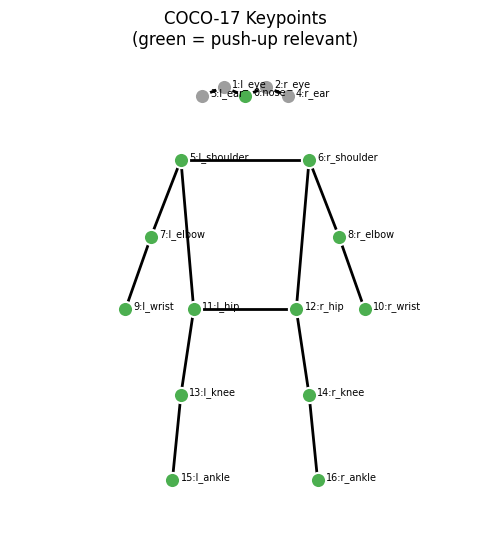

In [8]:
# Visualize the skeleton diagram (canonical layout)
COCO_KPS = [
    'nose','l_eye','r_eye','l_ear','r_ear',
    'l_shoulder','r_shoulder','l_elbow','r_elbow',
    'l_wrist','r_wrist','l_hip','r_hip',
    'l_knee','r_knee','l_ankle','r_ankle'
]

# Approximate canonical x,y positions for diagram
COCO_POS = np.array([
    [0.50, 0.05],  # nose
    [0.45, 0.03],  # l_eye
    [0.55, 0.03],  # r_eye
    [0.40, 0.05],  # l_ear
    [0.60, 0.05],  # r_ear
    [0.35, 0.20],  # l_shoulder
    [0.65, 0.20],  # r_shoulder
    [0.28, 0.38],  # l_elbow
    [0.72, 0.38],  # r_elbow
    [0.22, 0.55],  # l_wrist
    [0.78, 0.55],  # r_wrist
    [0.38, 0.55],  # l_hip
    [0.62, 0.55],  # r_hip
    [0.35, 0.75],  # l_knee
    [0.65, 0.75],  # r_knee
    [0.33, 0.95],  # l_ankle
    [0.67, 0.95],  # r_ankle
])

SKELETON = [
    (0,1),(0,2),(1,3),(2,4),   # head
    (5,6),(5,7),(7,9),(6,8),(8,10),  # arms
    (5,11),(6,12),(11,12),     # torso
    (11,13),(13,15),(12,14),(14,16)  # legs
]

PUSHUP_KPS = {0,5,6,7,8,9,10,11,12,13,14,15,16}

fig, ax = plt.subplots(figsize=(5, 9))
ax.set_xlim(-0.05,1.05); ax.set_ylim(-0.05,1.05)
ax.invert_yaxis()
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('COCO-17 Keypoints\n(green = push-up relevant)', fontsize=12)

for a,b in SKELETON:
    ax.plot([COCO_POS[a,0], COCO_POS[b,0]],
            [COCO_POS[a,1], COCO_POS[b,1]],
            'k-', lw=2, zorder=1)

for i,(x,y) in enumerate(COCO_POS):
    c = '#4CAF50' if i in PUSHUP_KPS else '#9E9E9E'
    ax.scatter(x, y, s=120, c=c, zorder=2, edgecolors='white', linewidths=1.5)
    ax.annotate(f'{i}:{COCO_KPS[i]}', (x,y),
                textcoords='offset points', xytext=(6,0), fontsize=7)

plt.tight_layout()
plt.show()

## 1.4 Run YOLO Pose on Sample Frames

In [9]:
# Use the smallest pose model for quick exploration
POSE_MODEL_NAME = 'yolo11n-pose.pt'   # downloaded automatically by ultralytics
pose_model = YOLO(POSE_MODEL_NAME)
print(f'Loaded pose model: {POSE_MODEL_NAME}')

Loaded pose model: yolo11n-pose.pt


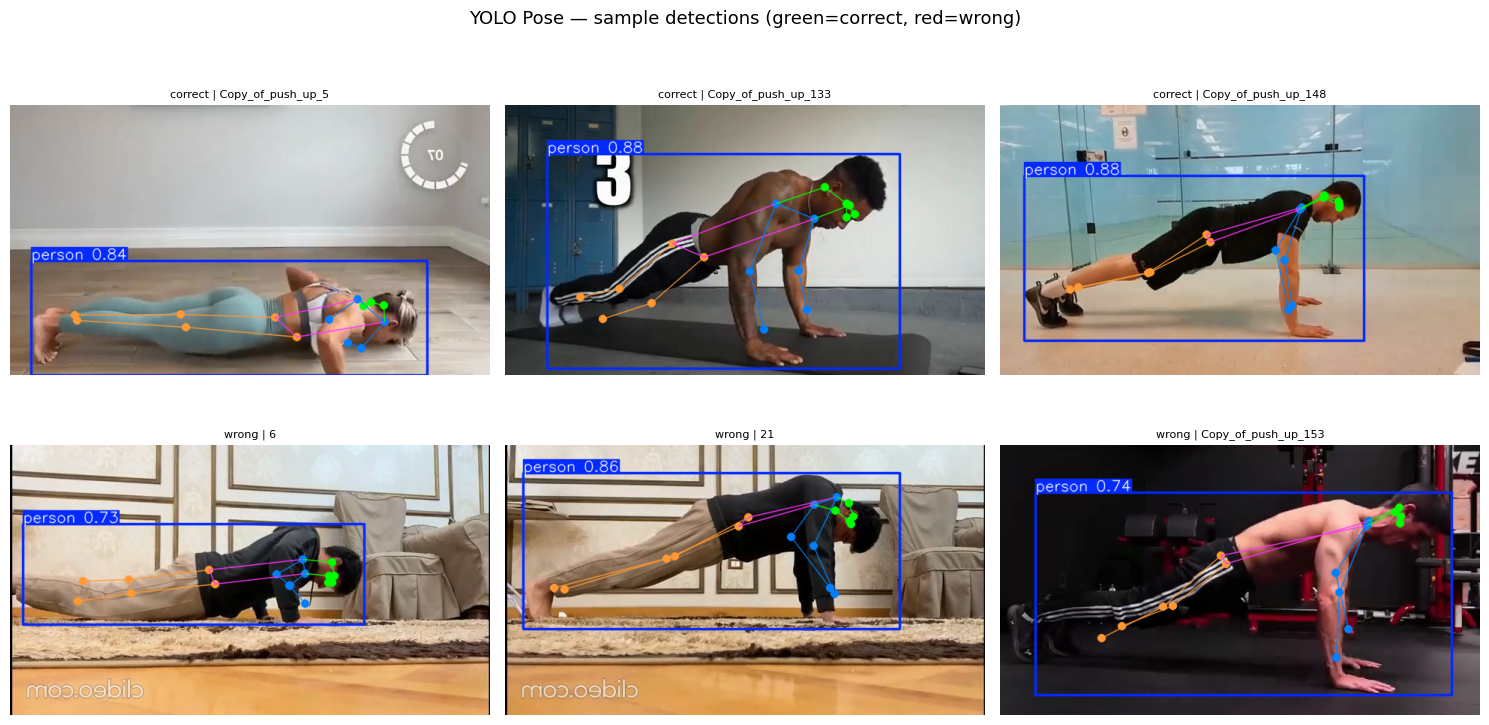

In [10]:
# Run on a few sample frames and visualise
CONF = 0.5

sample_correct = random.sample(correct_frames, min(3, len(correct_frames)))
sample_wrong   = random.sample(wrong_frames,   min(3, len(wrong_frames)))
samples = [(p, 'correct') for p in sample_correct] + [(p, 'wrong') for p in sample_wrong]

PUSHUP_COLOR = '#FF9800'

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (path, label) in zip(axes, samples):
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        ax.axis('off'); continue

    result = pose_model(img_bgr, conf=CONF, verbose=False)[0]
    ann    = result.plot()
    ax.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
    border_color = '#4CAF50' if label == 'correct' else '#F44336'
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color); spine.set_linewidth(3)
    ax.set_title(f'{label} | {path.parent.name}', fontsize=8)
    ax.axis('off')

fig.suptitle('YOLO Pose — sample detections (green=correct, red=wrong)', fontsize=13)
plt.tight_layout()
plt.show()

## 1.5 Keypoint Access Pattern

Shows how to extract raw `(x, y, conf)` values from a YOLO Pose result — this is the pattern used in notebook 2.

In [11]:
if correct_frames:
    sample_path = correct_frames[0]
    img_bgr = cv2.imread(str(sample_path))
    result  = pose_model(img_bgr, conf=CONF, verbose=False)[0]

    print(f'Image       : {sample_path.name}')
    print(f'People found: {len(result.keypoints)}')

    if result.keypoints is not None and len(result.keypoints) > 0:
        # Select the person with the largest bounding box (= closest)
        boxes = result.boxes.xyxy.cpu().numpy()  # (N, 4)
        areas = (boxes[:,2]-boxes[:,0]) * (boxes[:,3]-boxes[:,1])
        best  = int(np.argmax(areas))

        kps_full = result.keypoints.data.cpu().numpy()  # (N, 17, 3)
        kps      = kps_full[best]                       # (17, 3)  x,y,conf

        df = pd.DataFrame(kps, columns=['x','y','conf'])
        df.insert(0, 'name', COCO_KPS)
        df['visible'] = df['conf'] > 0.5
        print('\nKeypoints for closest person:')
        print(df.to_string(index=True))
    else:
        print('[NOTE] No person detected in this frame.')

Image       : Copy_of_push_up_1_f00000.jpg
People found: 1

Keypoints for closest person:
          name           x           y      conf  visible
0         nose  479.808899  192.073868  0.703790     True
1        l_eye  476.660858  188.008499  0.223552    False
2        r_eye  481.567963  181.222031  0.518436     True
3        l_ear  449.484253  177.440308  0.444987    False
4        r_ear  468.273743  166.463821  0.935994     True
5   l_shoulder  415.827698  185.652893  0.992454     True
6   r_shoulder  453.379517  159.207977  0.996445     True
7      l_elbow  384.024536  248.981415  0.824831     True
8      r_elbow  428.839508  223.112915  0.969475     True
9      l_wrist  434.819977  317.551208  0.492836    False
10     r_wrist  450.015381  290.323364  0.781173     True
11       l_hip  297.393585  188.350250  0.985366     True
12       r_hip  314.961121  167.006897  0.991185     True
13      l_knee  179.067139  241.822067  0.926907     True
14      r_knee  196.969971  228.072067  

## 1.6 Biomechanical Angle Preview

Verify that **elbow angle** and **body straightness** can be computed correctly from keypoints.

In [12]:
def angle_3pts(a, b, c):
    """Angle at vertex b formed by rays b→a and b→c, in degrees."""
    ba = np.array(a) - np.array(b)
    bc = np.array(c) - np.array(b)
    cos_a = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-9)
    return float(np.degrees(np.arccos(np.clip(cos_a, -1, 1))))


def compute_features(kps, conf_thresh=0.3):
    """
    kps: (17, 3) array  [x, y, conf]
    Returns dict of biomechanical features for one frame.
    """
    def pt(idx):
        return kps[idx, :2] if kps[idx, 2] > conf_thresh else None

    l_sh, r_sh = pt(5),  pt(6)   # shoulders
    l_el, r_el = pt(7),  pt(8)   # elbows
    l_wr, r_wr = pt(9),  pt(10)  # wrists
    l_hi, r_hi = pt(11), pt(12)  # hips
    l_kn, r_kn = pt(13), pt(14)  # knees
    l_an, r_an = pt(15), pt(16)  # ankles

    feats = {}

    # Elbow angles (shoulder → elbow → wrist)
    feats['left_elbow_angle']  = angle_3pts(l_sh, l_el, l_wr)  if all(v is not None for v in [l_sh, l_el, l_wr]) else np.nan
    feats['right_elbow_angle'] = angle_3pts(r_sh, r_el, r_wr)  if all(v is not None for v in [r_sh, r_el, r_wr]) else np.nan
    feats['elbow_symmetry']    = abs(feats['left_elbow_angle'] - feats['right_elbow_angle']) if not (np.isnan(feats['left_elbow_angle']) or np.isnan(feats['right_elbow_angle'])) else np.nan

    # Hip angle (shoulder → hip → knee)
    feats['left_hip_angle']  = angle_3pts(l_sh, l_hi, l_kn) if all(v is not None for v in [l_sh, l_hi, l_kn]) else np.nan
    feats['right_hip_angle'] = angle_3pts(r_sh, r_hi, r_kn) if all(v is not None for v in [r_sh, r_hi, r_kn]) else np.nan

    # Body straightness: deviation of hip from shoulder–ankle line
    if l_sh is not None and l_hi is not None and l_an is not None:
        # Fit line shoulder→ankle and measure perpendicular dist of hip
        sa = l_an - l_sh
        t  = np.dot(l_hi - l_sh, sa) / (np.dot(sa, sa) + 1e-9)
        proj = l_sh + t * sa
        feats['body_straightness_px'] = float(np.linalg.norm(l_hi - proj))
    else:
        feats['body_straightness_px'] = np.nan

    # Shoulder height (lower y = higher in image)
    if l_sh is not None and r_sh is not None:
        feats['shoulder_height'] = float((l_sh[1] + r_sh[1]) / 2)
    else:
        feats['shoulder_height'] = np.nan

    return feats


# ── Test on a few correct frames ───────────────────────────────────────────────
CONF_THRESH = 0.3
records = []

for path in tqdm(correct_frames[:30], desc='Computing features (sample)'):
    img_bgr = cv2.imread(str(path))
    if img_bgr is None: continue
    res = pose_model(img_bgr, conf=CONF_THRESH, verbose=False)[0]
    if res.keypoints is None or len(res.keypoints) == 0: continue
    boxes = res.boxes.xyxy.cpu().numpy()
    areas = (boxes[:,2]-boxes[:,0]) * (boxes[:,3]-boxes[:,1])
    best  = int(np.argmax(areas))
    kps   = res.keypoints.data.cpu().numpy()[best]
    feats = compute_features(kps, CONF_THRESH)
    feats['label'] = 'correct'
    feats['path']  = str(path)
    records.append(feats)

df_feats = pd.DataFrame(records)
print(df_feats[['left_elbow_angle','right_elbow_angle','elbow_symmetry',
                'body_straightness_px','shoulder_height']].describe().round(2))

Computing features (sample): 100%|██████████| 30/30 [00:01<00:00, 23.25it/s]

       left_elbow_angle  right_elbow_angle  elbow_symmetry  \
count             30.00              27.00           27.00   
mean             111.72             123.11           19.60   
std               28.51              38.45           12.33   
min               22.56               7.05            0.12   
25%              107.90             117.37           14.69   
50%              119.67             133.96           22.98   
75%              131.25             152.23           24.79   
max              136.58             160.90           63.78   

       body_straightness_px  shoulder_height  
count                 30.00            30.00  
mean                   8.00           205.51  
std                    7.48            34.97  
min                    0.10           172.43  
25%                    2.50           176.99  
50%                    6.24           183.87  
75%                   11.85           237.44  
max                   30.99           275.39  


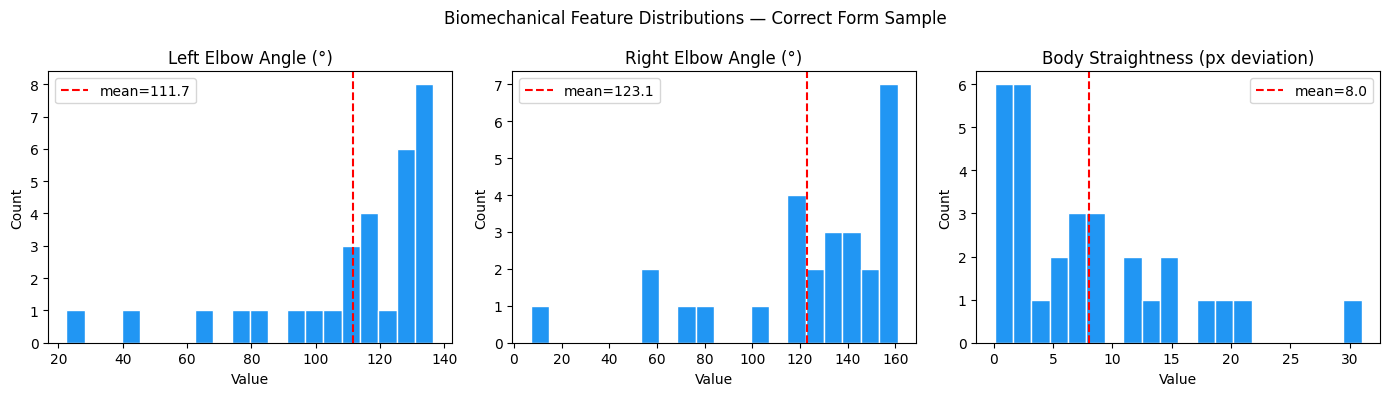

In [13]:
# Plot elbow angle distribution for sample correct frames
feat_cols = ['left_elbow_angle','right_elbow_angle','body_straightness_px']
titles    = ['Left Elbow Angle (°)', 'Right Elbow Angle (°)', 'Body Straightness (px deviation)']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(axes, feat_cols, titles):
    vals = df_feats[col].dropna()
    ax.hist(vals, bins=20, color='#2196F3', edgecolor='white')
    ax.axvline(vals.mean(), color='red', linestyle='--', label=f'mean={vals.mean():.1f}')
    ax.set_title(title); ax.set_xlabel('Value'); ax.set_ylabel('Count')
    ax.legend()

fig.suptitle('Biomechanical Feature Distributions — Correct Form Sample', fontsize=12)
plt.tight_layout()
plt.show()

## 1.7 Keypoint Confidence Analysis

Check which keypoints are consistently detected vs unreliable — this guides confidence thresholding in notebook 2.

Keypoint confidence probe: 100%|██████████| 80/80 [00:04<00:00, 18.82it/s]


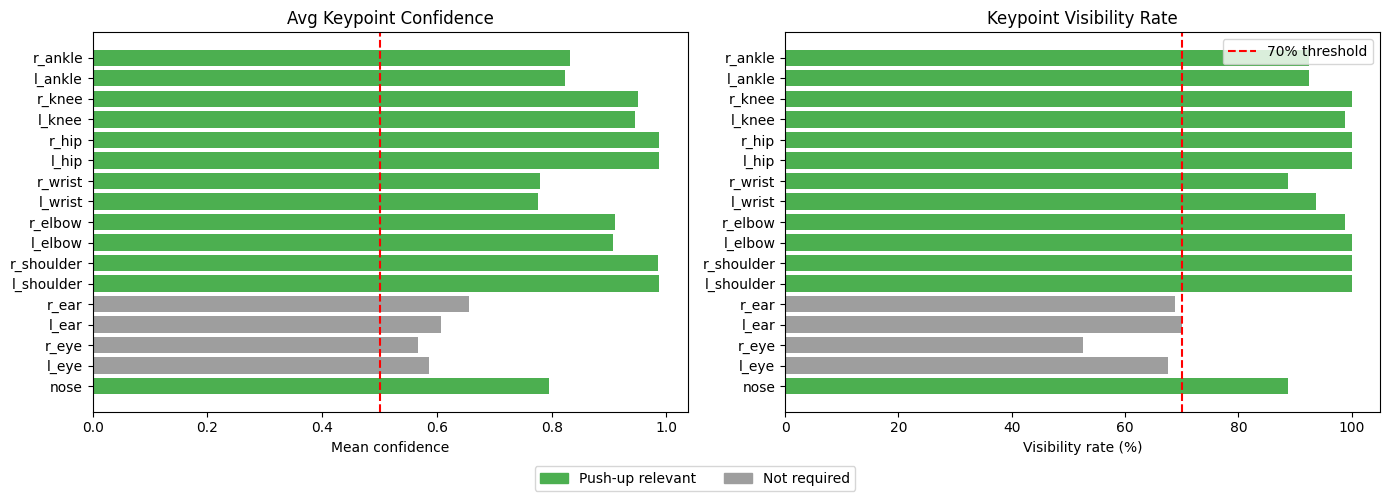

In [14]:
kp_conf_records = []

probe_frames = random.sample(correct_frames + wrong_frames,
                             min(80, len(correct_frames + wrong_frames)))

for path in tqdm(probe_frames, desc='Keypoint confidence probe'):
    img_bgr = cv2.imread(str(path))
    if img_bgr is None: continue
    res = pose_model(img_bgr, conf=0.3, verbose=False)[0]
    if res.keypoints is None or len(res.keypoints) == 0: continue
    boxes = res.boxes.xyxy.cpu().numpy()
    areas = (boxes[:,2]-boxes[:,0]) * (boxes[:,3]-boxes[:,1])
    best  = int(np.argmax(areas))
    confs = res.keypoints.data.cpu().numpy()[best, :, 2]   # (17,)
    kp_conf_records.append(confs)

if kp_conf_records:
    arr = np.array(kp_conf_records)       # (N, 17)
    mean_conf = arr.mean(axis=0)          # (17,)
    vis_rate  = (arr > 0.5).mean(axis=0)  # fraction of frames where visible

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    colors = ['#4CAF50' if i in PUSHUP_KPS else '#9E9E9E' for i in range(17)]

    ax1.barh(COCO_KPS, mean_conf, color=colors)
    ax1.axvline(0.5, color='red', linestyle='--')
    ax1.set_xlabel('Mean confidence'); ax1.set_title('Avg Keypoint Confidence')

    ax2.barh(COCO_KPS, vis_rate*100, color=colors)
    ax2.axvline(70, color='red', linestyle='--', label='70% threshold')
    ax2.set_xlabel('Visibility rate (%)'); ax2.set_title('Keypoint Visibility Rate')
    ax2.legend()

    patch_used   = mpatches.Patch(color='#4CAF50', label='Push-up relevant')
    patch_unused = mpatches.Patch(color='#9E9E9E', label='Not required')
    fig.legend(handles=[patch_used, patch_unused], loc='lower center', ncol=2)

    plt.tight_layout(rect=[0,0.05,1,1])
    plt.show()
else:
    print('[WARN] No keypoints collected — check that frames directory is populated.')

## 1.8 Summary & Checklist

| Check | Status |
|---|---|
| Frames extracted from person_detector | ✅ |
| YOLO Pose loads and runs successfully | ✅ |
| 17 COCO keypoints visible on push-up frames | ✅ |
| Elbow angle computable | ✅ |
| Body-straightness signal computable | ✅ |

**Next:** `2.data_preparation.ipynb` — run all YOLO Pose models over the full frame set and save structured keypoint outputs.